# Análisis de Ventas y Rendimiento Comercial

**Objetivo:** Analizar datos de ventas, clientes y campañas de marketing para identificar patrones de ingresos, productos de alto rendimiento y tendencias en el comportamiento de las ventas a lo largo del año 2024.

**Herramientas utilizadas:** Python · Pandas · NumPy · Matplotlib · Seaborn · Plotly

**Estructura del análisis:**
1. Carga de datos
2. Exploración inicial
3. Limpieza de datos
4. Transformación de variables
5. Análisis exploratorio
6. Visualización
7. Conclusiones
8. Limitaciones

## 1. Carga de Datos

In [1]:
# Librerías utilizadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
ventas    = pd.read_csv('../data/ventas.csv')
clientes  = pd.read_csv('../data/clientes.csv')
marketing = pd.read_csv('../data/marketing.csv')

## 2. Exploración Inicial

In [3]:
def analisis_exploratorio(df, nombre_df='DataFrame'):
    print(f'\n=== Análisis exploratorio de {nombre_df} ===\n')

    # Dimensiones
    print('Dimensiones:', df.shape)

    # Tipos de datos
    print('\nTipos de datos:')
    print(df.dtypes)

    # Valores nulos
    print('\nValores nulos por columna:')
    print(df.isnull().sum())

    # Estadísticas descriptivas
    print('\nEstadísticas descriptivas:')
    print(df.describe(include='all'))

    print(f'\n--- Fin del análisis de {nombre_df} ---\n')

analisis_exploratorio(ventas,    'Ventas')
analisis_exploratorio(clientes,  'Clientes')
analisis_exploratorio(marketing, 'Marketing')


=== Análisis exploratorio de Ventas ===

Dimensiones: (3035, 6)

Tipos de datos:
id_venta         int64
producto        object
precio          object
cantidad       float64
fecha_venta     object
categoria       object
dtype: object

Valores nulos por columna:
id_venta       0
producto       0
precio         2
cantidad       2
fecha_venta    0
categoria      0
dtype: int64

Estadísticas descriptivas:
           id_venta         producto  precio     cantidad fecha_venta  \
count   3035.000000             3035    3033  3033.000000        3035   
unique          NaN               30    2590          NaN         364   
top             NaN  Lámpara de mesa  $76.32          NaN  06/04/2024   
freq            NaN              181       5          NaN          24   
mean    1499.851400              NaN     NaN     6.496538         NaN   
std      866.465379              NaN     NaN     3.457250         NaN   
min        1.000000              NaN     NaN     1.000000         NaN   
25%      74

In [4]:
# Lista con los dataframes y sus nombres
dataframes = [
    ('clientes',  clientes),
    ('ventas',    ventas),
    ('marketing', marketing)
]

# Análisis de nulos y duplicados para cada uno
for nombre_df, df in dataframes:
    print(f'\nAnalisis de nulos y duplicados: {nombre_df}\n')

    # Nulos
    print('Valores nulos por columna:')
    nulos = df.isna().sum()

    if nulos.sum() > 0:
        print(nulos[nulos > 0])
        print(f'\nTotal de valores nulos en el DataFrame: {nulos.sum()}')
    else:
        print('No hay valores nulos en el DataFrame.')

    # Duplicados
    duplicados = df.duplicated().sum()
    print(f'\nCantidad de filas duplicadas: {duplicados}')

    if duplicados > 0:
        print('Existen filas duplicadas que podrían requerir limpieza.')
    else:
        print('No existen filas duplicadas.')

    print(f'\nFin del análisis de {nombre_df}\n')


Analisis de nulos y duplicados: clientes

Valores nulos por columna:
No hay valores nulos en el DataFrame.

Cantidad de filas duplicadas: 0
No existen filas duplicadas.

Fin del análisis de clientes


Analisis de nulos y duplicados: ventas

Valores nulos por columna:
precio      2
cantidad    2
dtype: int64

Total de valores nulos en el DataFrame: 4

Cantidad de filas duplicadas: 35
Existen filas duplicadas que podrían requerir limpieza.

Fin del análisis de ventas


Analisis de nulos y duplicados: marketing

Valores nulos por columna:
No hay valores nulos en el DataFrame.

Cantidad de filas duplicadas: 0
No existen filas duplicadas.

Fin del análisis de marketing



### Exploración inicial y evaluación de calidad de los datos

Se realizó un análisis exploratorio inicial (EDA) para comprender la estructura de los datasets y detectar posibles problemas de calidad antes de iniciar la etapa de limpieza.

Se analizaron dimensiones, tipos de datos, estadísticas descriptivas, valores nulos y registros duplicados.

**Principales hallazgos:**
- El dataset **ventas** presenta valores nulos en `precio` y `cantidad`, y 35 filas duplicadas. Además, `precio` está almacenado como texto.
- El dataset **clientes** no presenta valores nulos ni duplicados.
- El dataset **marketing** no presenta problemas de calidad, aunque las variables de fecha están almacenadas como texto.

En la siguiente etapa se realizará la limpieza y preparación de los datos.

## 3. Limpieza de Datos

In [5]:
def limpiar_datos(df, nombre_df):
    print(f'\n=== Limpieza de datos: {nombre_df} ===\n')

    # Crear copia para no modificar el original
    df_limpio = df.copy()

    # Eliminar duplicados
    duplicados = df_limpio.duplicated().sum()
    if duplicados > 0:
        df_limpio = df_limpio.drop_duplicates()
        print(f'Se eliminaron {duplicados} filas duplicadas.')
    else:
        print('No se encontraron filas duplicadas.')

    # Limpieza de columnas de texto
    columnas_texto = df_limpio.select_dtypes(include='object').columns

    for col in columnas_texto:
        df_limpio[col] = (
            df_limpio[col]
            .astype(str)
            .str.strip()
            .str.replace(r'\s+', ' ', regex=True)
        )

    print(f'Se limpiaron {len(columnas_texto)} columnas de texto.')
    print(f'Shape final: {df_limpio.shape}')
    print(f'--- Fin de la limpieza de {nombre_df} ---\n')

    return df_limpio

ventas_clean    = limpiar_datos(ventas,    'Ventas')
clientes_clean  = limpiar_datos(clientes,  'Clientes')
marketing_clean = limpiar_datos(marketing, 'Marketing')


=== Limpieza de datos: Ventas ===

Se eliminaron 35 filas duplicadas.
Se limpiaron 4 columnas de texto.
Shape final: (3000, 6)
--- Fin de la limpieza de Ventas ---


=== Limpieza de datos: Clientes ===

No se encontraron filas duplicadas.
Se limpiaron 2 columnas de texto.
Shape final: (567, 5)
--- Fin de la limpieza de Clientes ---


=== Limpieza de datos: Marketing ===

No se encontraron filas duplicadas.
Se limpiaron 4 columnas de texto.
Shape final: (90, 6)
--- Fin de la limpieza de Marketing ---



### Limpieza de datos

En esta etapa se realizó el proceso de limpieza de los datasets con el objetivo de mejorar la calidad de los datos antes del análisis.

Las principales tareas realizadas fueron:
- eliminación de registros duplicados
- limpieza de columnas de texto (espacios y caracteres innecesarios)
- verificación de la estructura final de los datasets

Este proceso permite trabajar con datos más consistentes para las etapas posteriores de análisis.

## 4. Transformación de Variables

### Transformación de la variable `precio`

La columna `precio` estaba almacenada como texto con el símbolo de moneda (`$`). Se eliminó el símbolo y se convirtió la variable a formato numérico para permitir cálculos y análisis estadísticos posteriores.

In [6]:
ventas_clean['precio'] = (
    ventas_clean['precio']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
)

ventas_clean['precio'] = pd.to_numeric(ventas_clean['precio'], errors='coerce')

### Cálculo del valor total de cada venta

Se crea la variable `total_venta`, que representa el ingreso generado por cada transacción.

In [7]:
ventas_clean['total_venta'] = ventas_clean['precio'] * ventas_clean['cantidad']

### Conversión de fechas

Las columnas de fecha estaban almacenadas como texto. Se convierten a formato `datetime` para poder realizar análisis temporales.

In [8]:
ventas_clean['fecha_venta'] = pd.to_datetime(
    ventas_clean['fecha_venta'], dayfirst=True, errors='coerce'
)

marketing_clean['fecha_inicio'] = pd.to_datetime(
    marketing_clean['fecha_inicio'], dayfirst=True, errors='coerce'
)
marketing_clean['fecha_fin'] = pd.to_datetime(
    marketing_clean['fecha_fin'], dayfirst=True, errors='coerce'
)

## 5. Análisis Exploratorio

### KPIs Principales del Negocio

Antes de profundizar en el análisis, se calculan las métricas de negocio fundamentales que permiten tener una visión general del rendimiento comercial del período.

In [9]:
ventas_totales  = ventas_clean['total_venta'].sum()
ticket_promedio = ventas_clean['total_venta'].mean()
unidades_totales = ventas_clean['cantidad'].sum()
n_transacciones = ventas_clean['id_venta'].count()

print('=== KPIs Principales ===')
print(f'Ventas totales:        ${ventas_totales:,.2f}')
print(f'Ticket promedio:       ${ticket_promedio:,.2f}')
print(f'Unidades vendidas:     {unidades_totales:,.0f}')
print(f'Total de transacciones: {n_transacciones:,}')

=== KPIs Principales ===
Ventas totales:        $1,467,093.52
Ticket promedio:       $489.36
Unidades vendidas:     19,495
Total de transacciones: 3,000


### Estadística Descriptiva

Se realizó un análisis de estadística descriptiva sobre las variables principales del dataset: precio, cantidad vendida y total de venta.

Para cada variable se calcularon medidas de tendencia central (media y mediana) y medidas de dispersión (desviación estándar, valores mínimos y máximos, y cuartiles).

In [10]:
ventas_clean[['precio', 'cantidad', 'total_venta']].describe()

,precio,cantidad,total_venta
count,2998.000000,2998.000000,2998.000000
mean,75.291318,6.502668,489.357412
std,28.736008,3.455107,334.281817
min,26.000000,1.000000,26.300000
25%,50.030000,3.000000,220.920000
50%,75.205000,7.000000,418.065000
75%,100.067500,9.000000,709.920000
max,124.970000,12.000000,1488.120000


In [11]:
precio_promedio = ventas_clean['precio'].mean()
precio_mediana  = ventas_clean['precio'].median()
precio_desvio   = ventas_clean['precio'].std()

cantidad_promedio = ventas_clean['cantidad'].mean()
cantidad_desvio   = ventas_clean['cantidad'].std()

print('Media del precio:', precio_promedio)
print('Mediana del precio:', precio_mediana)
print('Desvío estándar del precio:', precio_desvio)

print('Media de cantidad vendida:', cantidad_promedio)
print('Desvío estándar de cantidad vendida:', cantidad_desvio)

Media del precio: 75.29131754503001
Mediana del precio: 75.205
Desvío estándar del precio: 28.736008473949784
Media de cantidad vendida: 6.5026684456304205
Desvío estándar de cantidad vendida: 3.455106942116232


### Identificación de Productos de Alto Rendimiento

Se calcula el total de ventas por producto y se identifican aquellos que superan el percentil 80 de ingresos generados.

In [12]:
ventas_por_producto = (
    ventas_clean
    .groupby('producto')['total_venta']
    .sum()
    .reset_index()
    .sort_values(by='total_venta', ascending=False)
)

umbral_80 = ventas_por_producto['total_venta'].quantile(0.80)

print(f'Percentil 80 del total de ventas: {umbral_80:.2f}')

productos_alto_rendimiento = ventas_por_producto[
    ventas_por_producto['total_venta'] > umbral_80
]

productos_alto_rendimiento

Percentil 80 del total de ventas: 52518.85


,producto,total_venta
19,Lámpara de mesa,82276.38
3,Auriculares,74175.58
20,Microondas,72562.89
5,Cafetera,59607.31
9,Cuadro decorativo,54297.60
27,Smartphone,54132.44


### Análisis de Ventas por Categoría

Se agregan métricas de ventas a nivel de categoría de producto. Para cada categoría se calculan ingresos totales, precio promedio y cantidad total vendida.

In [13]:
resumen_categorias = ventas_clean.groupby('categoria').agg(
    total_ingresos=('total_venta', 'sum'),
    precio_promedio=('precio', 'mean'),
    cantidad_total=('cantidad', 'sum')
).reset_index()

resumen_categorias = resumen_categorias.sort_values(by='total_ingresos', ascending=False)

print('Resumen de ventas por categoría:')
resumen_categorias

Resumen de ventas por categoría:


,categoria,total_ingresos,precio_promedio,cantidad_total
1,Electrodomésticos,505299.63,76.52096,6592.0
2,Electrónica,482577.80,75.25492,6413.0
0,Decoración,479216.09,74.09800,6490.0


### Integración de Datos de Ventas y Marketing

Se integran los datasets de ventas y marketing utilizando la variable `producto` como clave de unión, lo que permite analizar la relación entre las ventas generadas y las campañas de marketing asociadas a cada producto.

In [14]:
ventas_marketing = pd.merge(
    ventas_clean,
    marketing_clean,
    on='producto',
    how='left'
)

ventas_marketing.head()

,id_venta,producto,precio,cantidad,fecha_venta,categoria,total_venta,id_campanha,canal,costo,fecha_inicio,fecha_fin
0,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,1,RRSS,5.27,2024-04-27,2024-06-04
1,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,31,Email,5.28,2024-08-15,2024-09-12
2,792,Cuadro decorativo,69.94,5.0,2024-01-02,Decoración,349.7,61,TV,5.30,2024-11-05,2024-12-23
3,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,32,Email,5.54,2024-03-28,2024-04-20
4,811,Lámpara de mesa,105.10,5.0,2024-01-02,Decoración,525.5,2,RRSS,5.88,2024-05-30,2024-06-29


> **Observación:** La unión de los datasets genera múltiples registros para algunos productos, ya que un mismo producto puede estar asociado a varias campañas de marketing en distintos canales. Esto permite analizar cómo diferentes estrategias de marketing se relacionan con el desempeño de ventas.

## 6. Visualización

### Distribución de Variables

Se utilizaron histogramas con estimación de densidad (KDE) para analizar la distribución de los datos, identificar posibles concentraciones de valores y detectar asimetrías.

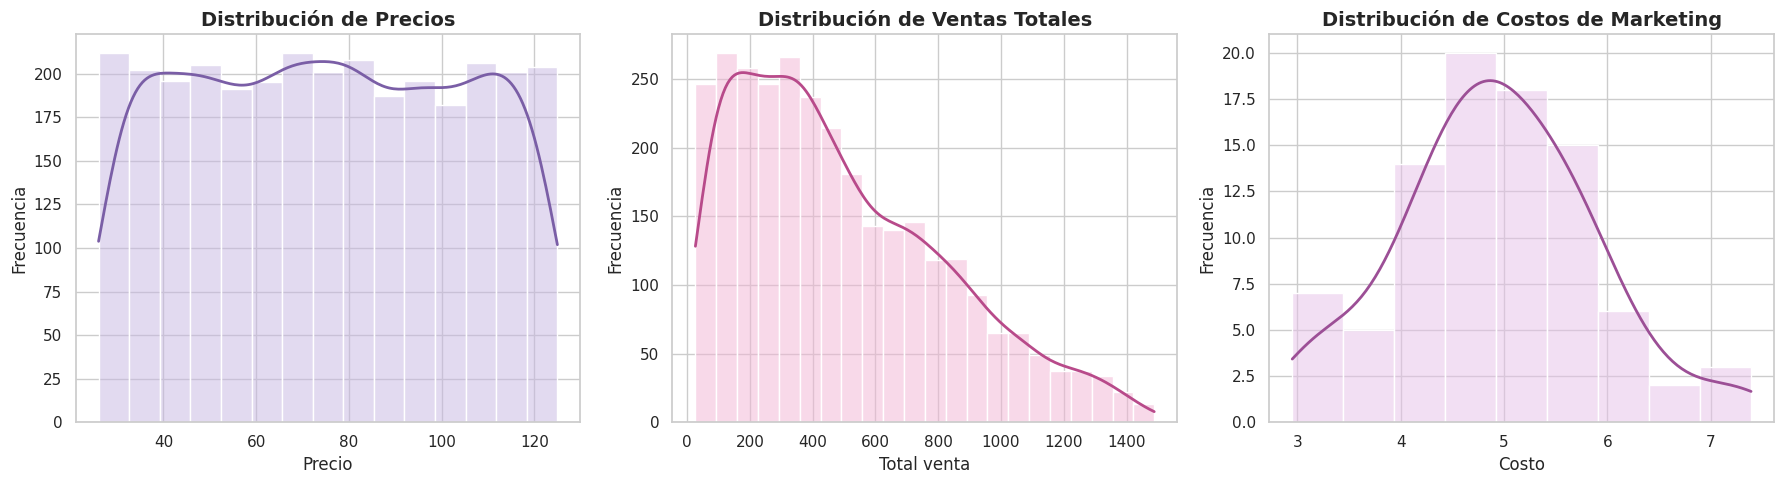

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

COL_PRECIO_BAR = '#C7B7E2'
COL_PRECIO_KDE = '#7A5EA6'

COL_VENTA_BAR  = '#F2B5D4'
COL_VENTA_KDE  = '#B84A8A'

COL_COSTO_BAR  = '#E6C1E8'
COL_COSTO_KDE  = '#9C4F96'

sns.set_theme(style='whitegrid')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# -------- Precio --------
sns.histplot(
    data=ventas_clean, x='precio', bins='auto', kde=True,
    edgecolor='white', color=COL_PRECIO_BAR, ax=axes[0]
)
for line in axes[0].lines:
    line.set_color(COL_PRECIO_KDE)
    line.set_linewidth(2)
axes[0].set_title('Distribución de Precios', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')

# -------- Total ventas --------
sns.histplot(
    data=ventas_clean, x='total_venta', bins='auto', kde=True,
    edgecolor='white', color=COL_VENTA_BAR, ax=axes[1]
)
for line in axes[1].lines:
    line.set_color(COL_VENTA_KDE)
    line.set_linewidth(2)
axes[1].set_title('Distribución de Ventas Totales', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total venta')
axes[1].set_ylabel('Frecuencia')

# -------- Marketing --------
sns.histplot(
    data=marketing_clean, x='costo', bins='auto', kde=True,
    edgecolor='white', color=COL_COSTO_BAR, ax=axes[2]
)
for line in axes[2].lines:
    line.set_color(COL_COSTO_KDE)
    line.set_linewidth(2)
axes[2].set_title('Distribución de Costos de Marketing', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Costo')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Análisis de Valores Atípicos

Los diagramas de caja (boxplots) permiten analizar la dispersión de las variables y detectar posibles valores atípicos.

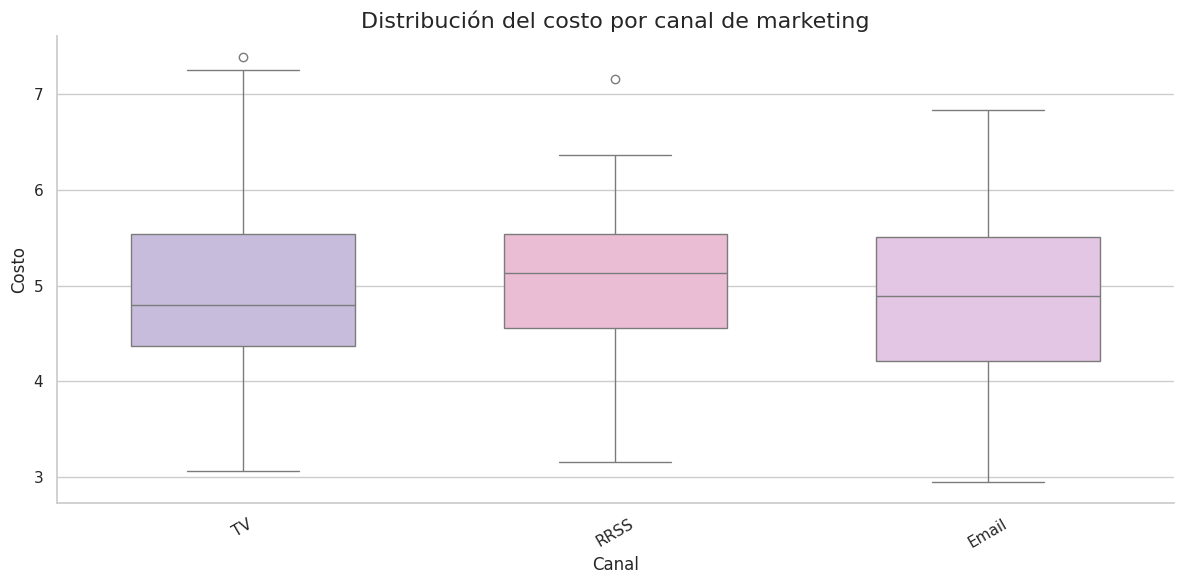

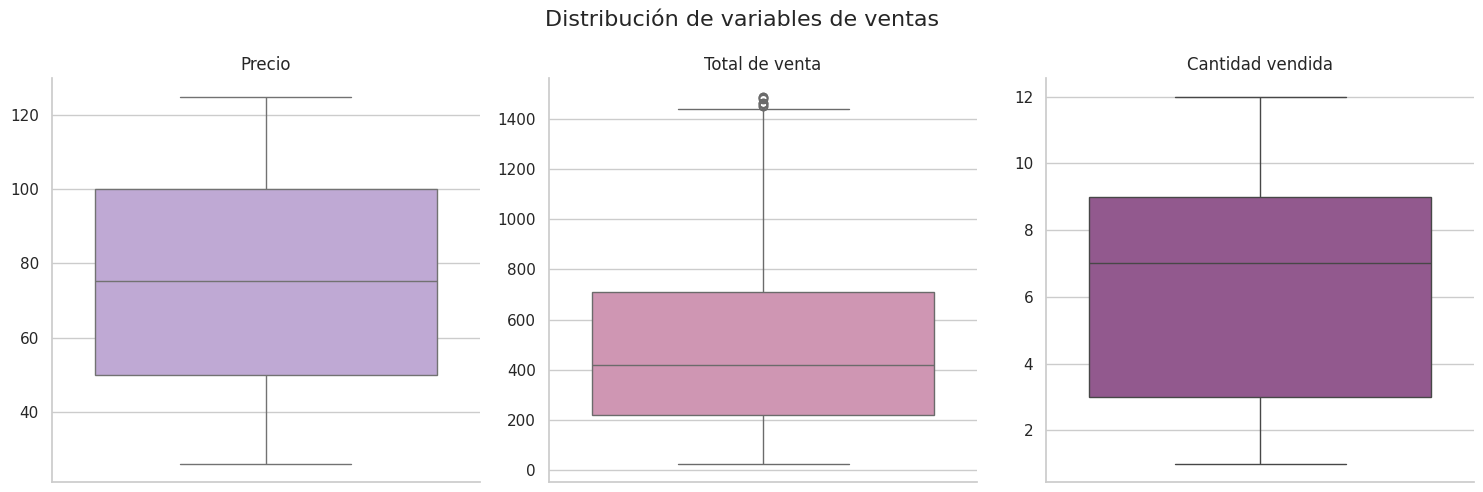

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

COL_CANAL    = ['#C7B7E2', '#F2B5D4', '#E6C1E8']
COL_PRECIO   = '#BFA2DB'
COL_VENTA    = '#D98CB3'
COL_CANTIDAD = '#9C4F96'

sns.set_theme(style='whitegrid')

# ── Boxplot: costo por canal (FutureWarning corregido) ──
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=marketing_clean,
    x='canal',
    y='costo',
    hue='canal',
    palette=COL_CANAL,
    legend=False,
    width=0.6
)

plt.title('Distribución del costo por canal de marketing', fontsize=16)
plt.xlabel('Canal')
plt.ylabel('Costo')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

# ── Boxplots: variables de ventas ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=ventas_clean, y='precio',      color=COL_PRECIO,   ax=axes[0])
axes[0].set_title('Precio')

sns.boxplot(data=ventas_clean, y='total_venta', color=COL_VENTA,    ax=axes[1])
axes[1].set_title('Total de venta')

sns.boxplot(data=ventas_clean, y='cantidad',    color=COL_CANTIDAD, ax=axes[2])
axes[2].set_title('Cantidad vendida')

for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.suptitle('Distribución de variables de ventas', fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

### Análisis de Correlación

Se calculó la matriz de correlación entre precio, cantidad vendida y total de venta para identificar la fuerza y dirección de la relación entre las variables.


Matriz de correlación:
               precio  cantidad  total_venta
precio       1.000000 -0.002388     0.558846
cantidad    -0.002388  1.000000     0.773009
total_venta  0.558846  0.773009     1.000000


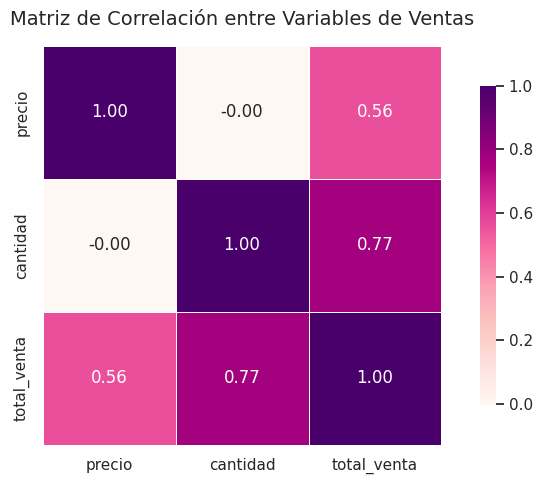

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_num = ventas_clean[['precio', 'cantidad', 'total_venta']]
correlacion   = variables_num.corr()

print('\nMatriz de correlación:')
print(correlacion)

plt.figure(figsize=(8, 5))
sns.heatmap(
    correlacion,
    annot=True,
    fmt='.2f',
    cmap='RdPu',
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlación entre Variables de Ventas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

### Evolución Temporal de las Ventas

Se agruparon los datos por mes para observar posibles tendencias o patrones temporales en el comportamiento de las ventas.

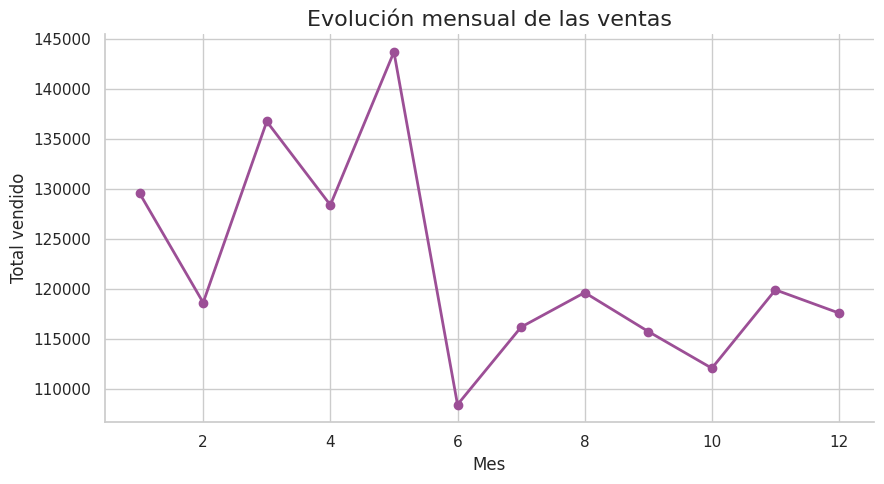

In [18]:
sns.set_theme(style='whitegrid')
COL_LINEA = '#9C4F96'

# Mes de venta
ventas_clean['mes'] = ventas_clean['fecha_venta'].dt.month

# Ventas por mes
ventas_mes = (
    ventas_clean
    .groupby('mes', as_index=False)
    .agg(total_ventas=('total_venta', 'sum'))
)

plt.figure(figsize=(9, 5))
plt.plot(
    ventas_mes['mes'], ventas_mes['total_ventas'],
    marker='o', linewidth=2, color=COL_LINEA
)
plt.title('Evolución mensual de las ventas', fontsize=16)
plt.xlabel('Mes')
plt.ylabel('Total vendido')
sns.despine()
plt.tight_layout()
plt.show()

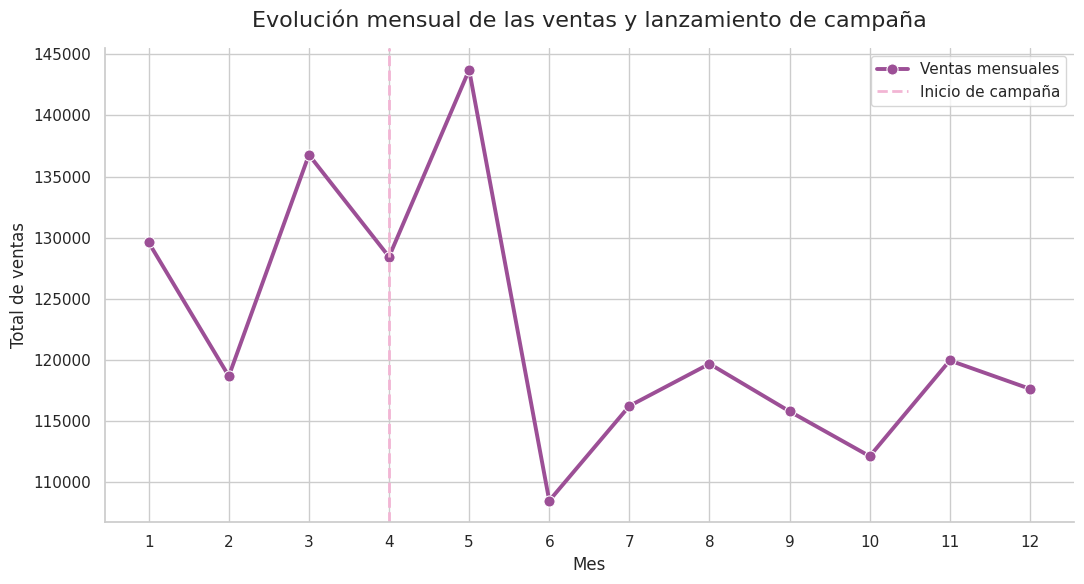

In [19]:
COL_VENTAS_LINEA = '#9C4F96'
COL_CAMPANIA     = '#F2B5D4'

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=ventas_mes,
    x='mes', y='total_ventas',
    linewidth=2.8, marker='o', markersize=8,
    color=COL_VENTAS_LINEA,
    label='Ventas mensuales'
)

plt.axvline(
    x=4, linestyle='--', linewidth=2,
    color=COL_CAMPANIA, label='Inicio de campaña'
)

plt.title('Evolución mensual de las ventas y lanzamiento de campaña', fontsize=16, pad=15)
plt.xlabel('Mes')
plt.ylabel('Total de ventas')
plt.xticks(range(1, 13))
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

### Gráficos Interactivos

In [20]:
df_plotly = ventas_clean.copy()
df_plotly = df_plotly.dropna(subset=['precio', 'cantidad', 'total_venta'])
df_plotly = df_plotly[df_plotly['total_venta'] > 0]
df_plotly['mes'] = df_plotly['fecha_venta'].dt.month

ventas_mes_plotly = (
    df_plotly
    .groupby('mes', as_index=False)
    .agg(total_ventas=('total_venta', 'sum'))
)

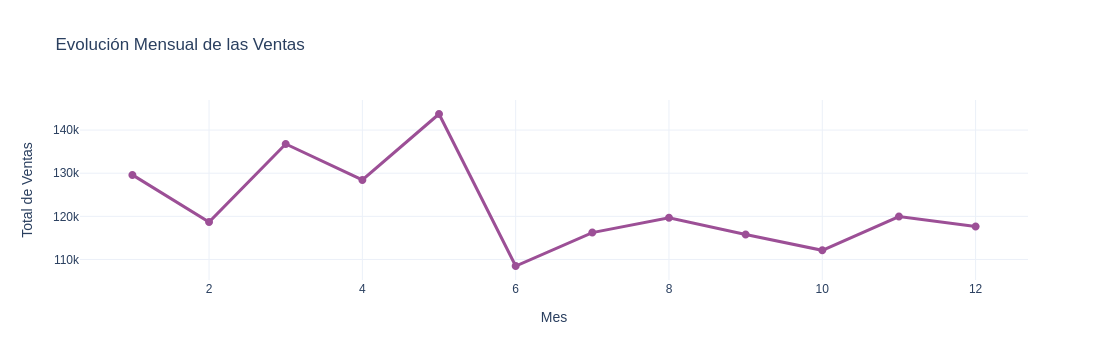

In [21]:
fig_linea = px.line(
    ventas_mes_plotly,
    x='mes', y='total_ventas',
    markers=True,
    title='Evolución Mensual de las Ventas',
    labels={'mes': 'Mes', 'total_ventas': 'Total de Ventas'},
    color_discrete_sequence=['#9C4F96']
)
fig_linea.update_traces(line=dict(width=3), marker=dict(size=8))
fig_linea.update_layout(template='plotly_white', hovermode='x unified')
fig_linea.show()

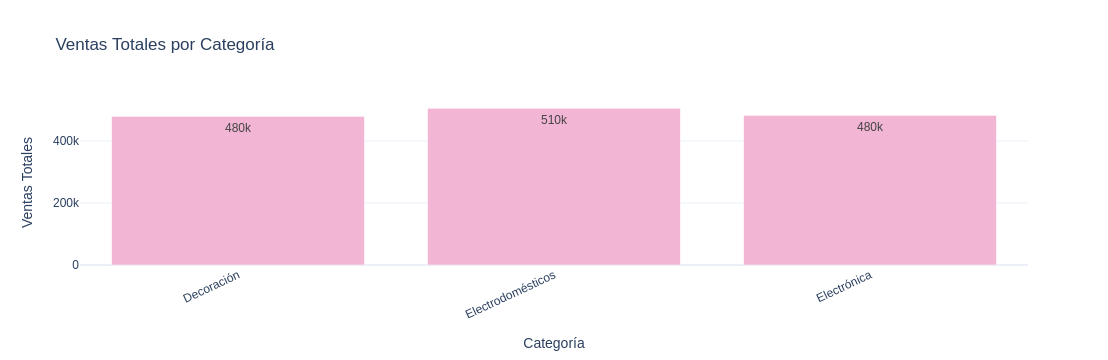

In [22]:
ventas_categoria = (
    df_plotly
    .groupby('categoria', as_index=False)
    .agg(total_ventas=('total_venta', 'sum'))
)

fig_barras = px.bar(
    ventas_categoria,
    x='categoria', y='total_ventas',
    title='Ventas Totales por Categoría',
    text_auto='.2s',
    labels={'categoria': 'Categoría', 'total_ventas': 'Ventas Totales'},
    color_discrete_sequence=['#F2B5D4']
)
fig_barras.update_layout(template='plotly_white', xaxis_tickangle=-25)
fig_barras.show()

## 7. Conclusiones

El análisis exploratorio permitió comprender el comportamiento general de las ventas y la relación entre las variables principales del dataset.

**Sobre las ventas:**
- La correlación entre cantidad vendida y total de ventas es alta (r = 0.77), lo que indica que el **volumen de unidades vendidas es el principal driver de ingresos** del negocio, por encima del precio (r = 0.56).
- Los productos de alto rendimiento (sobre el percentil 80) son: Lámpara de mesa, Auriculares, Microondas, Cafetera, Cuadro decorativo y Smartphone. Concentrar esfuerzos en estos productos puede maximizar los ingresos.
- La categoría **Electrodomésticos** lidera en ingresos totales, seguida por Electrónica y Decoración, con diferencias moderadas entre las tres.

**Sobre la evolución temporal:**
- El análisis mensual permite identificar variaciones en el volumen de ventas a lo largo del año. Las campañas de marketing iniciadas en el mes 4 podrían estar relacionadas con cambios en la tendencia de ventas del segundo semestre.

**Sobre el negocio:**
- El precio no parece afectar significativamente la cantidad vendida (r = -0.002), lo que sugiere que los clientes no son especialmente sensibles al precio dentro del rango analizado.

Estos resultados constituyen una base sólida para futuras etapas de análisis o para la toma de decisiones estratégicas relacionadas con las ventas y las estrategias de marketing.

## 8. Limitaciones del Análisis

Es importante señalar las siguientes limitaciones para una correcta interpretación de los resultados:

**Vinculación entre datasets:**
El dataset de clientes no está vinculado a las ventas mediante un `id_cliente`, por lo que no es posible analizar el comportamiento de compra por cliente, calcular el Customer Lifetime Value (CLV) ni identificar qué segmentos demográficos generan más ingresos.

**Atribución de marketing:**
El análisis de marketing no permite medir causalidad entre campañas y ventas. Se asume que los ingresos por producto están relacionados con las campañas, pero en la práctica las ventas pueden ocurrir sin que la campaña sea el factor determinante. No existe información de atribución ni grupos de control para validar el impacto real.

**Naturaleza del dataset:**
El dataset parece ser simulado, por lo que algunos resultados —como los costos de marketing extremadamente bajos en comparación con los ingresos— no reflejan escenarios reales de negocio. Las conclusiones deben interpretarse en ese contexto.